In [ ]:
!pip install --upgrade gensim nltk pyLDAvis preprocessor rake-nltk emoji langid bertopic
import os
os.kill(os.getpid(), 9)

#Library

In [1]:
import warnings
import re
import pickle
from collections import Counter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.util import ngrams
from nltk.sentiment import SentimentIntensityAnalyzer

import langid

from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import Phrases
from gensim.models.phrases import Phraser

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD
from sklearn.model_selection import GridSearchCV
from sklearn.metrics.pairwise import cosine_similarity

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

from tqdm import tqdm

from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use

In [2]:
# Download NLTK resources (only if missing)
for resource in ["stopwords", "punkt", "wordnet", "averaged_perceptron_tagger_eng", "vader_lexicon", "punkt_tab"]:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


#Lamar Comments

In [ ]:
import pandas as pd

# --- Data Loading ---
lamar_url = "https://docs.google.com/spreadsheets/d/1px_2vDyzwVzs5jYALfSjkmu2hqlY4niYszeRl9xJOFk/export?format=csv"
df_lamar = pd.read_csv(lamar_url)

# Alias df_lamar to df for compatibility with later cells
df = df_lamar

# If you want Usher later, you can uncomment these:
# usher_url = "https://docs.google.com/spreadsheets/d/1jbI5UvJ2Z1ibT3RhGQStt1sBAu6IbJB2Q0qA6bOiq6U/export?format=csv"
# df_usher = pd.read_csv(usher_url)

##Preprocessing

In [ ]:
import nltk
import re
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag

# --- Fix for AttributeError ---
# Explicitly load WordNet to prevent LazyCorpusLoader errors
try:
    wordnet.ensure_loaded()
except AttributeError:
    pass

# --- Preprocessing Setup ---
lemmatizer = nltk.WordNetLemmatizer()

# 1) Base stopwords
base_stopwords = set(stopwords.words("english"))

# 2) Bring back some short but meaningful words
#    (these are often useful in short YouTube comments)
keep_words = {"here", "again", "too", "same"}
base_stopwords = base_stopwords - keep_words

# 3) Custom stopwords specific to your domain
custom_stopwords = {
    "super", "bowl", "halftime", "show",
    "usher", "lamar", "kendrick",
    "im", "ive", "lol", "nfl",
    "ya", "yeah",

    # Existing pronouns and contractions
    "weve", "im", "whos", "hes", "whats", "they", "us", "the", "a", "an", "is", "are", "was", "were",
    "you", "we", "i", "what", "who", "youll", "your", "youre", "youd", "theyre", "be", "do",
    "would", "could", "should", "will",

    # Additional pronouns and related terms from tokenized list
    "that", "not", "cannot", "havenot", "willnot", "wouldnot", "either", "else",
    "anyone", "anybody", "everyone", "every", "other", "can",

    # Conversational fillers from tokenized list (common in social media discussions)
    "lol", "lmao", "haha", "hahaha", "wtf", "yeah", "yep", "yea", "yah", "hey", "whoop",
    "wow", "oops", "ummm", "ffs", "cmon", "lmaooo", "wth", "geez", "jeez",

    # Vague or generic terms from tokenized list
    "thing", "something", "anything", "everything", "stuff", "kind", "sort", "type",
    "nothing", "somewhat", "maybe", "perhaps", "anyway", "anymore",

    # High-frequency verbs and modifiers from tokenized list
    "get", "know", "think", "say", "seem", "seems", "look", "like", "want", "make",
    "take", "come", "try", "use", "sure", "really", "pretty", "actually", "basically",
    "totally", "absolutely", "probably", "definitely", "exactly", "always", "never",
    "still", "already", "yet", "almost", "sometimes"
    # you can add more slang here if you want
}

# --- Contractions handling ---

contractions_dict = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have",
    "'cause": "because", "could've": "could have", "couldn't": "could not", "couldn't've": "could not have",
    "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hadn't've": "had not have", "hasn't": "has not", "haven't": "have not", "he'd": "he would",
    "he'd've": "he would have", "he'll": "he will", "he'll've": "he will have", "he's": "he is",
    "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
    "i'd": "i would", "i'd've": "i would have", "i'll": "i will", "i'll've": "i will have",
    "i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
    "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have", "it's": "it is",
    "let's": "let us", "ma'am": "madam", "mayn't": "may not", "might've": "might have",
    "mightn't": "might not", "mightn't've": "might not have", "must've": "must have",
    "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not",
    "needn't've": "need not have", "o'clock": "of the clock", "oughtn't": "ought not",
    "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not",
    "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have",
    "she'll": "she will", "she'll've": "she will have", "she's": "she is",
    "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have",
    "so've": "so have", "so's": "so is", "that'd": "that would", "that'd've": "that would have",
    "that's": "that is", "there'd": "there would", "there'd've": "there would have",
    "there's": "there is", "they'd": "they would", "they'd've": "they would have",
    "they'll": "they will", "they'll've": "they will have", "they're": "they are",
    "they've": "they have", "to've": "to have", "wasn't": "was not", "we'd": "we would",
    "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
    "we've": "we have", "weren't": "were not", "what'll": "what will",
    "what'll've": "what will have", "what're": "what are", "what's": "what is",
    "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did",
    "where's": "where is", "where've": "where have", "who'll": "who will",
    "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is",
    "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
    "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have",
    "y'all": "you all", "y'all'd": "you all would", "y'all'd've": "you all would have",
    "y'all're": "you all are", "y'all've": "you all have", "you'd": "you would",
    "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
    "you're": "you are", "you've": "you have"
}

contractions_dict = {k.lower(): v for k, v in contractions_dict.items()}
contractions_re = re.compile("(%s)" % "|".join(map(re.escape, contractions_dict.keys())))

def expand_contractions(text: str) -> str:
    def replace(match):
        return contractions_dict[match.group(0)]
    return contractions_re.sub(replace, text)

# Final stopwords set
all_stopwords = base_stopwords | custom_stopwords

def get_wordnet_pos(treebank_tag):
    """Converts NLTK POS tags to WordNet POS tags for lemmatization"""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Default to noun if not found

def preprocess_comment(text, return_tokens=True, require_english=False):
    """Clean, expand contractions, tokenize, remove stopwords, and lemmatize one comment."""
    if not isinstance(text, str):
        return [] if return_tokens else ""
    if require_english and not is_english(text):
        return [] if return_tokens else ""

    # 1) Lowercase
    text = text.lower()

    # 2) Expand contractions BEFORE removing punctuation
    text = expand_contractions(text)

    # 3) Basic cleaning: URLs, mentions, hashtags, dates, numbers, punctuation
    text = re.sub(r'https?://\S+|www\.\S+', "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\d+/\d+/\d+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)

    # 4) Tokenization
    tokens = word_tokenize(text)

    # 5) Stopword removal
    tokens = [t for t in tokens if t not in all_stopwords]

    # 6) POS tagging + lemmatization
    tagged = pos_tag(tokens)
    lemmas = [
        lemmatizer.lemmatize(w, get_wordnet_pos(pos))
        for w, pos in tagged
        if w.isalpha() and len(w) >= 2   # <-- relaxed from > 2
    ]

    if return_tokens:
        return lemmas
    return " ".join(lemmas)

# --- Applying the Preprocessing ---
# Use df_lamar since that is what you loaded
df_lamar["tokens"] = df_lamar["text"].apply(
    lambda x: preprocess_comment(x, return_tokens=True, require_english=False)
)

df_lamar["processed_text"] = df_lamar["text"].apply(
    lambda x: preprocess_comment(x, return_tokens=False, require_english=False)
)

In [ ]:
# --- Displaying Results ---
print("--- Lamar Data Preview ---")
print(df_lamar[["text", "processed_text", "tokens"]].head())

--- Lamar Data Preview ---
                                                text        processed_text  \
0                            ight im back here again  ight back here again   
1                                        Me too 😂😂😂😂                   too   
2                                               Same                  same   
3                                            Me 3😂😂😂                         
4  I have never gone back to a super bowl halftim...     go back much ever   

                      tokens  
0  [ight, back, here, again]  
1                      [too]  
2                     [same]  
3                         []  
4     [go, back, much, ever]  


In [ ]:
# Select the 'title' column for LDA Topic modeling
text = df_lamar['processed_text']

# Drop rows with NaN values in the 'Title' column
text = text.dropna()

print(text)

0                    ight back here again
1                                     too
2                                    same
3                                        
4                       go back much ever
                       ...               
169841                               love
169842    way bring sam jackson uncle sam
169843                              first
169844                               shut
169845                              first
Name: processed_text, Length: 169846, dtype: object


In [ ]:
from gensim.models import Phrases
from gensim.models.phrases import Phraser

# -------------------------------
# Process your pandas Series of comments
# -------------------------------
# Assume `text` is your input Series
# Ensure 'text' is defined from previous cell
if 'text' not in globals():
    # Fallback if the previous cell wasn't run
    if 'df_lamar' in globals():
        text = df_lamar['processed_text'].dropna()
    else:
        raise NameError("Variable 'text' or 'df_lamar' not found. Please run the Data Loading and Preprocessing cells.")

text = text.drop_duplicates(keep='first').reset_index(drop=True)
processed_comments = text.apply(preprocess_comment)
processed_comments = processed_comments[processed_comments.map(lambda x: len(x) > 0)].reset_index(drop=True)

# -------------------------------
# Apply Bigram modeling
# -------------------------------
bigram = Phrases(processed_comments, min_count=5, threshold=10)
bigram_mod = Phraser(bigram)
processed_bigram_comments = processed_comments.apply(lambda x: bigram_mod[x])

# Final output
data_ready = processed_bigram_comments
print(data_ready)

0                                   [ight_back, here_again]
1                                                     [too]
2                                                    [same]
3                                    [go, back, much, ever]
4                                                   [drake]
                                ...                        
111470                                   [drake, bot, spot]
111471                   [inagine, ninja, low, taper, fade]
111472                                   [ill, able, start]
111473                           [full, half_time, channel]
111474    [whole_stadium, scream, minorrr, somebody_chec...
Name: processed_text, Length: 111475, dtype: object


#EDA (Exploratory Data Analysis)

In [ ]:
# Get all unique words across all tokenized titles
# Filter out NaN values before iterating
all_words = [word for text_tokens in data_ready.dropna() for word in text_tokens]

# Create a set of unique words
unique_words = set(all_words)

print("Total documents:", len(data_ready))
print("Average document length:", np.mean([len(doc) for doc in data_ready.dropna()])) # Also filter for average length
print("Unique words:", len(unique_words))

Total documents: 111475
Average document length: 5.4431128055617854
Unique words: 47670


[('drake', 11013), ('performance', 9630), ('watch', 7613), ('time', 5597), ('one', 5584), ('love', 5550), ('people', 4462), ('see', 4147), ('go', 4004), ('good', 3990), ('song', 3944), ('well', 3162), ('music', 3152), ('best', 3135), ('here', 3132), ('great', 3106), ('back', 2895), ('even', 2579), ('man', 2574), ('bad', 2557), ('ever', 2490), ('sza', 2429), ('superbowl', 2325), ('black', 2117), ('again', 2060), ('way', 2049), ('need', 1972), ('bro', 1957), ('dont', 1917), ('too', 1857)]


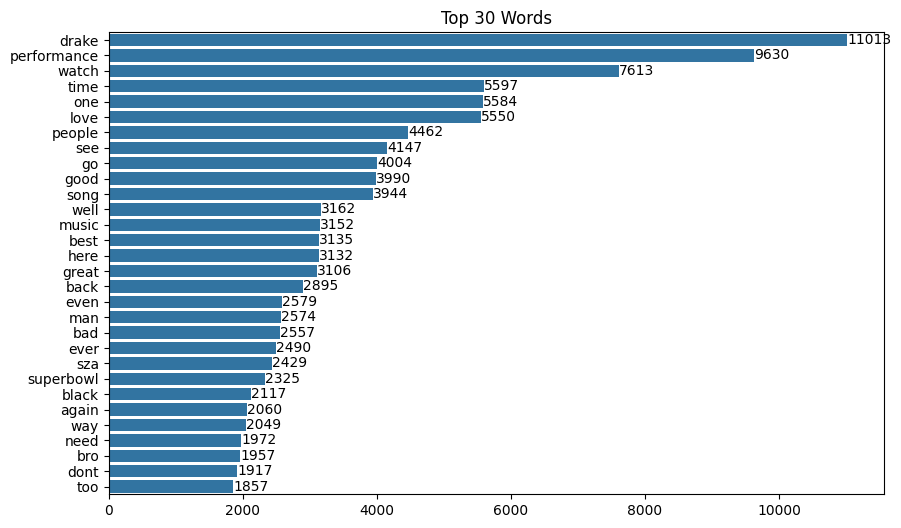

Top Bigrams: [(('half', 'time'), 2117), (('uncle', 'sam'), 1036), (('gon', 'na'), 968), (('samuel', 'jackson'), 943), (('turn', 'tv'), 898), (('hip', 'hop'), 878), (('time', 'watch'), 857), (('come', 'back'), 805), (('serena', 'williams'), 772), (('million', 'view'), 646), (('one', 'best'), 609), (('back', 'again'), 589), (('back', 'here'), 584), (('ever', 'see'), 575), (('many', 'time'), 563), (('get', 'ta'), 562), (('say', 'drake'), 559), (('th', 'time'), 551), (('here', 'again'), 534), (('best', 'performance'), 515)]


In [ ]:
from collections import Counter
from nltk.util import ngrams
import matplotlib.pyplot as plt
import seaborn as sns

# Word Frequency
# Flatten the list of lists into a single list of words
all_words = [word for text_tokens in data_ready.dropna() for word in text_tokens]

word_freq = Counter(all_words)  # Count word frequencies
top_words = word_freq.most_common(30)
print(top_words)

# Plot Top Words
words, counts = zip(*top_words)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(counts), y=list(words))  # Store the Axes object
plt.title("Top 30 Words")

# Add word counts as text annotations
for p in ax.patches:  # Iterate through the bars (patches)
    width = p.get_width()  # Get the width of the bar
    ax.text(width + 1,       # Position the text slightly to the right of the bar
            p.get_y() + p.get_height() / 2,  # Vertically center the text within the bar
            '{:1.0f}'.format(width),  # Format the count (remove decimal part)
            ha="left", va="center")  # Align the text

plt.show()

# Bigrams
# Assuming 'text' is your original Series of titles before tokenization
bigrams = Counter(ngrams(text.str.cat(sep=' ').split(), 2)).most_common(20)
print("Top Bigrams:", bigrams)

#LDA Topic Model (Topic number optimization)



In [ ]:
#Build corpus & dictionary
def build_corpus(tokens_series, no_below=5, no_above=0.5):
    texts = [t for t in tokens_series if isinstance(t, list) and len(t) > 0]
    dictionary = Dictionary(texts)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(text) for text in texts]
    return corpus, dictionary, texts

corpus, dictionary, texts = build_corpus(df_lamar["tokens"])

##Coherence Score

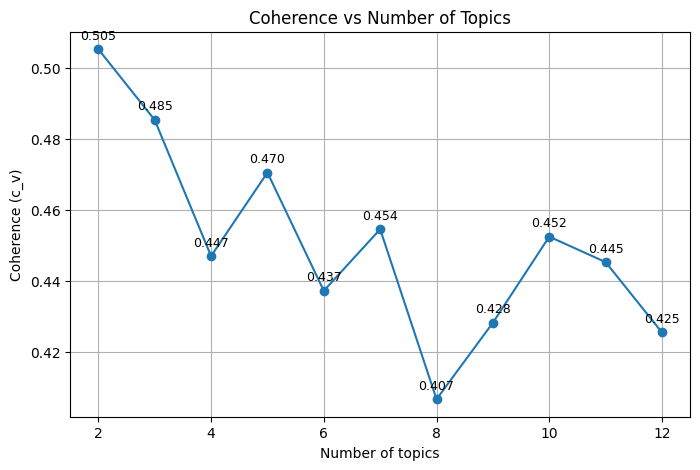

In [ ]:
def compute_coherence_curve(corpus, dictionary, texts, k_min=2, k_max=15, step=1):
    topic_nums = list(range(k_min, k_max + 1, step))
    coherences = []
    for k in topic_nums:
        lda_model = LdaModel(corpus=corpus,
                             id2word=dictionary,
                             num_topics=k,
                             random_state=42,
                             passes=10,
                             alpha="auto")
        cm = CoherenceModel(model=lda_model,
                            texts=texts,
                            dictionary=dictionary,
                            coherence="c_v")
        coherences.append(cm.get_coherence())
    return topic_nums, coherences

topic_nums, coherences = compute_coherence_curve(corpus, dictionary, texts, k_min=2, k_max=12)

plt.figure(figsize=(8,5))
plt.plot(topic_nums, coherences, marker="o")

# 🔹 Add the coherence numbers on the figure
for x, y in zip(topic_nums, coherences):
    plt.text(
        x, y + 0.002,              # a tiny vertical offset so text is above the dot
        f"{y:.3f}",                # format to 3 decimal places
        ha="center", va="bottom",
        fontsize=9
    )

plt.xlabel("Number of topics")
plt.ylabel("Coherence (c_v)")
plt.title("Coherence vs Number of Topics")
plt.grid(True)
plt.show()


In [ ]:
best_k = 3  # set based on the plot
lda_model = LdaModel(corpus=corpus,
                     id2word=dictionary,
                     num_topics=best_k,
                     random_state=42,
                     passes=20,
                     alpha="auto")

# Show topics
for i, topic in lda_model.print_topics(num_topics=best_k, num_words=10):
    print(f"Topic {i}: {topic}")

# pyLDAvis visualization
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
vis

Topic 0: 0.025*"performance" + 0.018*"time" + 0.015*"song" + 0.014*"one" + 0.013*"best" + 0.012*"ever" + 0.012*"get" + 0.012*"great" + 0.011*"good" + 0.010*"people"
Topic 1: 0.142*"drake" + 0.032*"say" + 0.017*"here" + 0.017*"bro" + 0.016*"jackson" + 0.014*"kdot" + 0.014*"smile" + 0.014*"back" + 0.014*"sam" + 0.014*"na"
Topic 2: 0.053*"love" + 0.033*"sza" + 0.029*"man" + 0.028*"tv" + 0.020*"minor" + 0.019*"turn" + 0.015*"amaze" + 0.012*"dot" + 0.011*"boring" + 0.011*"star"


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.381158 -0.049915       1        1  61.419970
1      0.234428 -0.300456       2        1  20.244093
2      0.146730  0.350371       3        1  18.335937, topic_info=          Term          Freq         Total Category  logprob  loglift
9        drake  21092.000000  21092.000000  Default  30.0000  30.0000
98        love   7090.000000   7090.000000  Default  29.0000  29.0000
66         say   4835.000000   4835.000000  Default  28.0000  28.0000
615        sza   4478.000000   4478.000000  Default  27.0000  27.0000
184        man   3848.000000   3848.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
757     humble    865.074521    865.816698   Topic3  -5.0488   1.6954
1040  euphoria    868.471140    869.243697   Topic3  -5.0448   1.6954
64         que    746.314449    746.997629   Topic3  -5.1964   1.6954
753     scream    927.800236    928.655711   Topic3  -4.9788   1.6954
1091      drop    842.472850    843.285662   Topic3  -5.0752   1.6953

[122 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
0         2  0.998985  again
348       3  0.999499  amaze
1         2  0.999668   back
13        1  0.999924    bad
1089      2  0.999541   beef
...     ...       ...    ...
478       1  0.999919   well
578       1  0.999794  whole
996       2  0.998816    win
662       3  0.999751   work
317       1  0.999858   year

[92 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3])

##Stability and Perplexity Score

In [ ]:
# Prepare data for topic modeling (Scikit-Learn expects strings)
data_ready_sklearn = [' '.join(tokens) for tokens in data_ready]  # Join tokens for Scikit-Learn

# Step 1: Build Scikit-Learn LDA Model with 3 Topics
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
data_vectorized = vectorizer.fit_transform(data_ready_sklearn)

lda_sklearn = LatentDirichletAllocation(n_components=4, learning_decay=0.5, random_state=42)
lda_sklearn.fit(data_vectorized)

LatentDirichletAllocation(learning_decay=0.5, n_components=4, random_state=42)

###Stability Score

In [ ]:
# Function to calculate stability score for a given number of topics
def calculate_stability(n_components, data, n_runs=5, random_states=range(5)):
    topic_distributions = []
    for seed in random_states:
        lda_temp = LatentDirichletAllocation(n_components=n_components, random_state=seed)
        lda_temp.fit(data)
        topic_distributions.append(lda_temp.components_)

    # Compute pairwise cosine similarities between consecutive topic matrices
    pairwise_similarities = [
        cosine_similarity(a, b).mean()
        for a, b in zip(topic_distributions[:-1], topic_distributions[1:])
    ]
    # Return average stability score
    return np.mean(pairwise_similarities)

# Range of topics to evaluate (focused around the optimal number)
topic_range = range(2, 16)  # From 2 to 15 topics
stability_scores = []

# Calculate stability for each number of topics
for n_topics in topic_range:
    score = calculate_stability(n_components=n_topics, data=data_vectorized)
    stability_scores.append(score)
    print(f"Stability for {n_topics} topics: {score}")

# Specific stability for the optimal number of topics (3)
optimal_topics = 3
optimal_score = calculate_stability(n_components=optimal_topics, data=data_vectorized)
print(f"Stability score for the optimal number of topics ({optimal_topics}): {optimal_score}")

# Plot stability scores
plt.figure(figsize=(8, 5))
plt.plot(topic_range, stability_scores, marker='o', linestyle='-', label="Stability Scores")
plt.axvline(x=optimal_topics, color='red', linestyle='--', label=f"Optimal Topics ({optimal_topics})")
plt.title("Stability Scores for Different Numbers of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Stability Score")
plt.grid(True)
plt.legend()
plt.show()

Stability for 2 topics: 0.5942691288842659
Stability for 3 topics: 0.4490459014927364
Stability for 4 topics: 0.38026722568860705
Stability for 5 topics: 0.3261206650912285
Stability for 6 topics: 0.276028867322607


###Perplexity Score

In [ ]:
# Use the data prepared in previous cells (data_ready_sklearn)
# (Removed dummy data lines so we analyze the actual dataset)

# Vectorize data
# We fit a new vectorizer here to ensure independence for this specific score calculation if needed,
# or we could reuse the previous one. Re-fitting is safer for standalone logic.
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
data_vectorized = vectorizer.fit_transform(data_ready_sklearn)

# Function to calculate perplexity score
def calculate_perplexity(n_components, data):
    lda_temp = LatentDirichletAllocation(n_components=n_components, random_state=42)
    lda_temp.fit(data)
    return lda_temp.perplexity(data)

# Range of topics to evaluate (focused around the optimal number)
topic_range = range(2, 16)  # From 2 to 15 topics
perplexity_scores = []

# Calculate perplexity for each number of topics
for n_topics in topic_range:
    perplexity_score = calculate_perplexity(n_components=n_topics, data=data_vectorized)
    perplexity_scores.append(perplexity_score)
    print(f"Topics: {n_topics}, Perplexity: {perplexity_score}")

# Specific perplexity for the optimal number of topics
optimal_topics = 3
optimal_perplexity = calculate_perplexity(n_components=optimal_topics, data=data_vectorized)
print(f"Optimal Number of Topics: {optimal_topics}, Perplexity: {optimal_perplexity}")

# Plot perplexity scores
plt.figure(figsize=(8, 5))

# Perplexity Scores
plt.plot(topic_range, perplexity_scores, marker='s', linestyle='-', label='Perplexity Score')

# Highlight Optimal Topics
plt.axvline(x=optimal_topics, color='red', linestyle='--', label=f"Optimal Topics ({optimal_topics})")

# Formatting the Plot
plt.title("Perplexity Scores for Different Numbers of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Perplexity Score")
plt.legend()
plt.grid(True)
plt.show()

#LDA Modeling

In [ ]:
# Re-define build_corpus function from cell TVI5OYD2BtZB
def build_corpus(tokens_series, no_below=5, no_above=0.5):
    texts = [t for t in tokens_series if isinstance(t, list) and len(t) > 0]
    dictionary = Dictionary(texts)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(text) for text in texts]
    return corpus, dictionary, texts

# Re-run the corpus and dictionary creation using df_lamar["tokens"]
# Assuming df_lamar and its "tokens" column are available in the kernel from prior execution.
corpus, dictionary, texts = build_corpus(df_lamar["tokens"])

# 1) Fit LDA
num_topics = 3  # or best_k from coherence

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=100,
    update_every=1,
    chunksize=10,
    passes=10,
    alpha="symmetric",
    iterations=100,
    per_word_topics=True,
)

for i, topic in lda_model.print_topics(num_topics=num_topics, num_words=10):
    print(f"Topic {i}: {topic}")


In [ ]:
from tqdm import tqdm

# 2) Dominant topic per document
def format_topics_sentences(ldamodel, corpus, texts_tokens, texts_raw):
    sent_topics_list = []

    for i, row_list in tqdm(enumerate(ldamodel[corpus])):
        row = row_list[0] if ldamodel.per_word_topics else row_list
        row = sorted(row, key=lambda x: x[1], reverse=True)

        topic_num, prop_topic = row[0]
        wp = ldamodel.show_topic(topic_num)
        topic_keywords = ", ".join([word for word, prop in wp])
        sent_topics_list.append(
            [int(topic_num), round(prop_topic, 4), topic_keywords]
        )

    # Base topic info
    sent_topics_df = pd.DataFrame(
        sent_topics_list,
        columns=["Dominant_Topic", "Perc_Contribution", "Topic_Keywords"],
    )

    # Attach tokenized and original text
    df_tokens = pd.DataFrame({"Tokenized_Text": list(texts_tokens)})
    df_raw = pd.DataFrame({"Original_Text": list(texts_raw)})

    # Align indices
    sent_topics_df = sent_topics_df.reset_index(drop=True)
    df_tokens = df_tokens.reset_index(drop=True)
    df_raw = df_raw.reset_index(drop=True)

    sent_topics_df = pd.concat(
        [sent_topics_df, df_tokens, df_raw],
        axis=1
    )

    return sent_topics_df


# Call it with BOTH tokens and original text
df_dominant_topic = format_topics_sentences(
    ldamodel=lda_model,
    corpus=corpus,
    texts_tokens=df_lamar["tokens"],   # tokenized / processed
    texts_raw=df_lamar["text"],        # original comments
)

df_dominant_topic.head()


In [ ]:
# 3) Save results (CSV + pickle) and optionally the model
out_base = "/content/drive/MyDrive/Data/SBHT/SBHT_Lamar_comment"

df_dominant_topic.to_csv(out_base + ".csv", index=False)
df_dominant_topic.to_pickle(out_base + ".pkl")

lda_model.save(out_base + "_lda_model.gensim")


# 4) Representative text per topic
pd.options.display.max_colwidth = 200  # or 100 if you prefer

sent_topics_sorteddf = pd.DataFrame()
sent_topics_outdf_grpd = df_dominant_topic.groupby("Dominant_Topic")

for i, grp in sent_topics_outdf_grpd:
    # Take the comment with highest contribution for each topic
    top_row = grp.sort_values(["Perc_Contribution"], ascending=False).head(1)
    sent_topics_sorteddf = pd.concat([sent_topics_sorteddf, top_row], axis=0)

sent_topics_sorteddf.reset_index(drop=True, inplace=True)

# Rename for nicer presentation
sent_topics_sorteddf = sent_topics_sorteddf[
    ["Dominant_Topic", "Perc_Contribution", "Topic_Keywords",
     "Original_Text", "Tokenized_Text"]
]

sent_topics_sorteddf.columns = [
    "Topic_Num",
    "Topic_Perc_Contrib",
    "Keywords",
    "Representative_Text",
    "Representative_Tokens",
]

sent_topics_sorteddf.head(10)

In [ ]:
import json
import numpy as np
import pyLDAvis
from pyLDAvis import gensim_models

# Define a new encoder
class CleanJSONEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.complex128, np.complex64)):
            return float(obj.real)
        if isinstance(obj, (np.float32, np.float64)):
            return float(obj)
        if isinstance(obj, (np.int32, np.int64)):
            return int(obj)
        return super().default(obj)

# Patch pyLDAvis encoder (important step)
pyLDAvis.utils.json = json
pyLDAvis.utils.json.JSONEncoder = CleanJSONEncoder


# Visualize topics with pyLDAvis
# Fixed: using 'dictionary' instead of undefined 'text_dict'
lda_display = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.display(lda_display)

#BERTopic + Fine-tuning + Gemini

In [3]:
# =========================================
# 0) Install
# =========================================
!pip -q install -U bertopic umap-learn hdbscan sentence-transformers google-genai xlsxwriter

import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

import os
import re
import time
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from umap import UMAP
from bertopic import BERTopic
import plotly.io as pio

from sentence_transformers import SentenceTransformer, models, datasets, losses
from torch.utils.data import DataLoader

from google.colab import userdata, drive
from google import genai
from google.genai import types

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.6/426.6 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 24.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.43.0, but you have google-auth 2.45.0 which is incompatible.


In [4]:
# =========================================
# 0.5) Repro + Drive
# =========================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# =========================================
# 1) Device
# =========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: Fine-tuning on CPU will be very slow. Enable GPU in Runtime > Change runtime type.")

Using device: cuda


In [6]:
# =========================================
# 2) Gemini API Key + Client Setup
# =========================================
GOOGLE_API_KEY = userdata.get("Gemini_Key")
if not GOOGLE_API_KEY:
    raise ValueError("Missing Gemini_Key in Colab Secrets.")

client = genai.Client(api_key=GOOGLE_API_KEY)

GEMINI_MODEL = "gemini-3-flash-preview"
GEMINI_SLEEP_SEC = 0.8  # increase if you see 429/rate-limit

SYSTEM_INSTRUCTION = (
    "You are a social media topic labeling professional. "
    "Your goal is to provide specific, descriptive labels for YouTube comment clusters. "
    "Rules: Max 7 words. No single letters. No abbreviations. Return ONLY the label using English. If you have to use different language to label the topic, then translate the label into English."
)


In [7]:
# =========================================
# 3) Load & Clean Data
# =========================================
lamar_url = "https://docs.google.com/spreadsheets/d/1px_2vDyzwVzs5jYALfSjkmu2hqlY4niYszeRl9xJOFk/export?format=csv"
df = pd.read_csv(lamar_url)

if "text" not in df.columns:
    raise ValueError("Your CSV must contain a column named 'text'.")

# FIX 1: Deduplicate FIRST
# The paper emphasizes removing duplicates early.
initial_count = len(df)
df = df.drop_duplicates(subset=['text'])
print(f"Removed {initial_count - len(df)} duplicate rows.")

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove User Mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # FIX 2: Remove Timestamps (CRITICAL for YouTube)
    # This prevents comments like "10:00" from forming their own topic
    text = re.sub(r'\b\d{1,2}:\d{2}\b', '', text)

    # FIX 3: Remove Emojis & Special Characters
    # The paper explicitly removed special characters/emojis.
    # This regex keeps only words and whitespace.
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df["clean_text"] = df["text"].apply(clean_text)

# FIX 4: Filter by Word Count (> 3 words)
# The paper filtered uninformative content. For comments, word count
# is more reliable than character count (len >= 10).
df = df[df["clean_text"].apply(lambda x: len(x.split()) > 3)].copy()

# Final Check for empties
df = df[df["clean_text"] != ""]

docs = df["clean_text"].tolist()
# Save raw docs to align with clean docs for later export
raw_docs = df["text"].astype(str).tolist()

print(f"Total documents to process: {len(docs)}")

# TSDAE Preparation
MAX_TSDAE_DOCS = 50000
if len(docs) > MAX_TSDAE_DOCS:
    idx = np.random.choice(len(docs), MAX_TSDAE_DOCS, replace=False)
    docs_tsdae = [docs[i] for i in idx]
else:
    docs_tsdae = docs


Removed 23745 duplicate rows.
Total documents to process: 111752


In [8]:
# =========================================
# 4) Fine-Tune Embedding Model (TSDAE)
# =========================================
import os
os.environ["WANDB_DISABLED"] = "true"  # disable wandb logs (optional)

print("\n--- Starting Domain Adaptation (TSDAE Fine-Tuning) ---")

from sentence_transformers import SentenceTransformer, models, datasets, losses
from torch.utils.data import DataLoader

# A) Use a multilingual base model (safer when multilingual minority exists)
# Recommended:
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
# Alternative:
# model_name = "sentence-transformers/distiluse-base-multilingual-cased-v2"

# Build SentenceTransformer explicitly (matches your original structure)
word_embedding_model = models.Transformer(model_name)
pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode="mean"
)
embedding_model = SentenceTransformer(modules=[word_embedding_model, pooling_model], device=device)

# (Recommended) cap max sequence length for speed/memory
embedding_model.max_seq_length = 256

# B) Denoising dataset adds noise on-the-fly (TSDAE)
# If docs_tsdae is not defined, fall back to docs
docs_for_tsdae = docs_tsdae if "docs_tsdae" in globals() else docs

train_dataset = datasets.DenoisingAutoEncoderDataset(docs_for_tsdae)

# Batch size: start at 32 for T4; if OOM, try 16; if plenty VRAM, try 64
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True)

# C) TSDAE loss (decoder matches the same base model)
train_loss = losses.DenoisingAutoEncoderLoss(
    embedding_model,
    decoder_name_or_path=model_name,
    tie_encoder_decoder=True
)

# D) Train (1 epoch is typical for domain adaptation)
# use_amp=True gives speed + lower VRAM on T4
embedding_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,
    weight_decay=0.0,
    scheduler="constantlr",
    optimizer_params={"lr": 3e-5},
    show_progress_bar=True,
    use_amp=True
)

print("--- Fine-Tuning Complete. Model adapted to dataset. ---")



--- Starting Domain Adaptation (TSDAE Fine-Tuning) ---


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

...

Some weights of BertLMHeadModel were not initialized from the model checkpoint at sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 and are newly initialized: ['bert.encoder.layer.0.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.0.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.0.crossattention.output.dense.bias', 'bert.encoder.layer.0.crossattention.output.dense.weight', 'bert.encoder.layer.0.crossattention.self.key.bias', 'bert.encoder.layer.0.crossattention.self.key.weight', 'bert.encoder.layer.0.crossattention.self.query.bias', 'bert.encoder.layer.0.crossattention.self.query.weight', 'bert.encoder.layer.0.crossattention.self.value.bias', 'bert.encoder.layer.0.crossattention.self.value.weight', 'bert.encoder.layer.1.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.1.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.1.crossattention.output.dense.bias', 'bert.encoder.layer.1.crossattention.output.dense.weight', 'bert.encoder.laye

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Step,Training Loss
500,7.719800
1000,5.952200
1500,5.515400
2000,5.271500
2500,5.125800
3000,4.999500
3500,4.895400
4000,4.829700
4500,4.773800
5000,4.695900


--- Fine-Tuning Complete. Model adapted to dataset. ---


In [9]:
# =========================================
# 5) Encode Embeddings Once (reuse for BERTopic + outlier reduction + galaxy view)
# =========================================
print("\nEncoding embeddings for all documents...")
embeddings = embedding_model.encode(
    docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False
)



Encoding embeddings for all documents...


Batches:   0%|          | 0/1747 [00:00<?, ?it/s]

In [10]:
# =========================================
# 6) Fit BERTopic (Using Fine-Tuned Model + Precomputed Embeddings)
# =========================================
# ---- UMAP ----
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED
)

# ---- BERTopic ----
topic_model = BERTopic(
    embedding_model=embedding_model,   # you can keep this even when passing embeddings
    umap_model=umap_model,
    min_topic_size=50,
    language="english",
    verbose=True
)

# ---- Fit with precomputed embeddings ----
topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)

# ---- Fix 1: Reduce outliers ONLY if there are any (-1) ----
n_outliers = sum(t == -1 for t in topics)
print(f"\nOutliers detected: {n_outliers}")

if n_outliers > 0:
    print("Reducing outliers...")
    new_topics = topic_model.reduce_outliers(
        docs,
        topics,
        strategy="embeddings",
        embeddings=embeddings
    )

    # Update topics after outlier reduction
    topic_model.update_topics(docs, topics=new_topics)
    topics = new_topics  # keep local variable aligned
else:
    print("No outliers to reduce — skipping reduce_outliers().")

# ---- Re-fetch representative docs AFTER updating topics (or skipping) ----
topic_to_docs = topic_model.get_representative_docs()

# ---- Optional: quick inspection ----
print("\nTopic counts (top 10):")
print(topic_model.get_topic_info().head(10))

# If you want: representative docs for a specific topic
# example_topic_id = 0
# print(topic_to_docs.get(example_topic_id, []))

2025-12-29 16:57:32,227 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-29 17:01:37,936 - BERTopic - Dimensionality - Completed ✓
2025-12-29 17:01:37,940 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-29 17:01:58,129 - BERTopic - Cluster - Completed ✓
2025-12-29 17:01:58,170 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-29 17:01:59,715 - BERTopic - Representation - Completed ✓



Outliers detected: 64299
Reducing outliers...


2025-12-29 17:02:01,345 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



Topic counts (top 10):
   Topic  Count                        Name  \
0      0  10783       0_drake_drakes_say_he   
1      1   4331  1_kendrick_lamar_love_goat   
2      2  12713             2_and_to_of_the   
3      3   3579              3_de_que_el_la   
4      4   3396  4_best_ever_halftime_worst   
5      5   2900          5_love_im_loved_it   
6      6   2552   6_this_is_man_performance   
7      7   2559             7_up_on_bro_the   
8      8   1450   8_halftime_best_this_show   
9      9   1782            9_he_did_his_him   

                                      Representation  \
0  [drake, drakes, say, he, hey, at, his, smile, ...   
1  [kendrick, lamar, love, goat, is, sza, you, ki...   
2  [and, to, of, the, but, you, people, that, it,...   
3         [de, que, el, la, es, en, un, lo, se, los]   
4  [best, ever, halftime, worst, show, time, half...   
5  [love, im, loved, it, see, dont, like, thought...   
6  [this, is, man, performance, so, what, music, ...   
7  [up, on

In [11]:
# =========================================
# 7) Gemini Labeling
# =========================================
def is_bad_label(label: str) -> bool:
    if not label:
        return True
    label = label.strip()
    if len(label) <= 2:
        return True
    # require at least 2 words
    if len(label.split()) < 2:
        return True
    # reject labels that are basically punctuation / numbers
    if re.fullmatch(r"[\W\d_]+", label):
        return True
    # reject any single-letter tokens
    if any(len(tok) == 1 for tok in label.split()):
        return True
    return False

def safe_response_text(resp) -> str:
    # google-genai typically provides resp.text, but keep a fallback
    txt = getattr(resp, "text", None)
    if txt:
        return str(txt)
    try:
        # fallback: dig into candidates
        return resp.candidates[0].content.parts[0].text
    except Exception:
        return ""

def gemini_label(topic_id: int, retries: int = 2) -> str:
    topic_words = topic_model.get_topic(topic_id) or []
    kws = [w for w, _ in topic_words[:10]]

    reps = topic_to_docs.get(topic_id, [])[:8]
    reps_block = "\n".join(f"- {d[:240]}" for d in reps) if reps else "- (no representative docs)"

    prompt = (
        f"Keywords: {', '.join(kws) if kws else '(none)'}\n\n"
        f"Sample text:\n{reps_block}\n\n"
        "Based on these, provide a descriptive label."
    )

    backoff = GEMINI_SLEEP_SEC
    for _ in range(retries + 1):
        try:
            cfg_kwargs = dict(
                system_instruction=SYSTEM_INSTRUCTION,
                temperature=0.2,
                max_output_tokens=30,
            )

            # Thinking config (Gemini 3 Flash supports minimal/low/medium/high)
            try:
                cfg_kwargs["thinking_config"] = types.ThinkingConfig(thinking_level="minimal")
            except Exception:
                pass

            resp = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt,
                config=types.GenerateContentConfig(**cfg_kwargs),
            )

            label = safe_response_text(resp).strip().strip('"')
            if not is_bad_label(label):
                return label

        except Exception as e:
            print(f"Error on Topic {topic_id}: {e}")

        time.sleep(backoff)
        backoff = min(backoff * 1.6, 6.0)

    # Fallback label
    if kws:
        return " ".join([k.title() for k in kws[:3]])
    return "General Discussion"

topic_ids = topic_model.get_topic_info()["Topic"].tolist()
labels = {}
for t in tqdm(topic_ids, desc="Labeling Topics"):
    if t == -1:
        labels[t] = "Outlier"
    else:
        labels[t] = gemini_label(t)

# Set topic labels (dict is allowed)
topic_model.set_topic_labels(labels)

Labeling Topics: 100%|██████████| 103/103 [02:22<00:00,  1.38s/it]


In [12]:
# =========================================
# 7.5) Create topic_summary_enriched (Sentiment Analysis)
# =========================================
print("\n--- Running Sentiment Analysis to create topic_summary_enriched ---")

import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. Load Sentiment Model (CardiffNLP XLM-R)
SENT_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(SENT_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(SENT_MODEL).to(device)
model.eval()

# 2. Define Batch Inference Function
def get_sentiment_scores(texts, batch_size=64):
    probs_all = []
    # Ensure all texts are strings
    texts = [str(t) for t in texts]

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        probs_all.append(probs)

    return np.vstack(probs_all)

# 3. Run Inference on ALL docs
print(f"Scoring {len(docs)} documents (this may take a minute)...")
sent_probs = get_sentiment_scores(docs, batch_size=64)

# 4. Create DataFrame with Scores
# columns: 0=Negative, 1=Neutral, 2=Positive
df_sent = pd.DataFrame(sent_probs, columns=["sent_neg", "sent_neu", "sent_pos"])
df_sent["sent_compound"] = df_sent["sent_pos"] - df_sent["sent_neg"]
df_sent["sent_conf"] = df_sent[["sent_neg", "sent_neu", "sent_pos"]].max(axis=1)

# Polished Label Logic (Confidence < 0.60 -> Neutral)
df_sent["sent_label_polished"] = df_sent[["sent_neg", "sent_neu", "sent_pos"]].idxmax(axis=1).map(
    {"sent_neg": "negative", "sent_neu": "neutral", "sent_pos": "positive"}
)
df_sent.loc[df_sent["sent_conf"] < 0.60, "sent_label_polished"] = "neutral"

# 5. Merge with Document Info (to get Topics)
# Ensure doc_info exists and is aligned
doc_info = topic_model.get_document_info(docs).reset_index(drop=True)
doc_info = pd.concat([doc_info, df_sent], axis=1)

# 6. Aggregate by Topic to create 'topic_summary_enriched'
print("Aggregating stats by Topic...")
agg_cols = ["sent_compound", "sent_pos", "sent_neg", "sent_neu", "sent_conf"]
stats = doc_info.groupby("Topic")[agg_cols].mean().reset_index()

# Calculate % Positive per Topic
def get_pos_pct(x): return (x == "positive").mean()
pos_pct = doc_info.groupby("Topic")["sent_label_polished"].apply(get_pos_pct).reset_index(name="pct_positive")

# Merge everything into the final table
topic_summary_enriched = topic_model.get_topic_info().copy()
topic_summary_enriched = pd.merge(topic_summary_enriched, stats, on="Topic", how="left")
topic_summary_enriched = pd.merge(topic_summary_enriched, pos_pct, on="Topic", how="left")

# Map your Gemini labels (if they exist)
if 'labels' in globals():
    topic_summary_enriched["CustomName"] = topic_summary_enriched["Topic"].map(labels)
else:
    topic_summary_enriched["CustomName"] = topic_summary_enriched["Name"]

print(f"✅ topic_summary_enriched created with {len(topic_summary_enriched)} topics.")
print(topic_summary_enriched[["Topic", "CustomName", "sent_compound", "pct_positive"]].head())


--- Running Sentiment Analysis to create topic_summary_enriched ---


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Scoring 111752 documents (this may take a minute)...
Aggregating stats by Topic...
✅ topic_summary_enriched created with 103 topics.
   Topic                                         CustomName  sent_compound  \
0      0   Kendrick Lamar smiling while saying Drake's name      -0.252554   
1      1  Expressing love and admiration for Kendrick Lamar       0.225975   
2      2  Mixed reactions to Kendrick Lamar halftime per...      -0.122736   
3      3  Analysis of Kendrick Lamar's performance and a...      -0.045273   
4      4         Best Super Bowl halftime shows of all-time       0.203565   

   pct_positive  
0      0.106371  
1      0.437312  
2      0.252104  
3      0.286672  
4      0.570082  


In [13]:
# =========================================
# 8) Export & Save
# =========================================
output_path = "/content/drive/MyDrive/Data/SBHT/lamar_bertopic_finetuned_results.xlsx"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

topic_summary = topic_model.get_topic_info().copy()
topic_summary["CustomName"] = topic_summary["Topic"].map(labels)

doc_info = topic_model.get_document_info(docs).copy()
doc_info["RawText"] = raw_docs

with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    topic_summary.to_excel(writer, sheet_name="Topic_Summary", index=False)
    doc_info.to_excel(writer, sheet_name="Assignments", index=False)

print(f"✅ Exported to: {output_path}")

✅ Exported to: /content/drive/MyDrive/Data/SBHT/lamar_bertopic_finetuned_results.xlsx


In [14]:
# =========================================
# 9) Visualize Topics
# =========================================
pio.renderers.default = "colab"
fig_topics = topic_model.visualize_topics(custom_labels=True)
fig_topics.show()

In [15]:
# =========================================
# 10) "Galaxy" View (white background, big)
# =========================================
print("\nCreating Galaxy View...")
reduced_embeddings = UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED
).fit_transform(embeddings)


Creating Galaxy View...


In [16]:
fig_docs = topic_model.visualize_documents(
    docs,
    reduced_embeddings=reduced_embeddings,
    custom_labels=True,
    hide_annotations=True,  # <--- Removes text from the middle of the plot
    hide_document_hover=False
)

fig_docs.update_layout(
    showlegend=True,  # <--- Forces the Legend (side labels) to appear
    template="plotly_white",
    width=2500,
    height=2000,
    margin=dict(l=40, r=520, t=60, b=40),
    legend=dict(
        font=dict(size=12),
        bgcolor="rgba(255,255,255,0.85)",
        yanchor="top",
        y=1,
        x=1.02  # Places legend slightly to the right
    )
)

fig_docs.update_xaxes(showline=True, linewidth=1, linecolor="black", zeroline=True, zerolinecolor="black")
fig_docs.update_yaxes(showline=True, linewidth=1, linecolor="black", zeroline=True, zerolinecolor="black")

fig_docs.show()

Output hidden; open in https://colab.research.google.com to view.

#Multilingual Sentiment Analysis (CardiffNLP XLM-R)

Using device: cuda
Running sentiment analysis...
=== Overall Sentiment Summary (XLM-R CardiffNLP) ===
avg_compound    0.076
avg_pos         0.408
avg_neg         0.332
avg_neu         0.260
dtype: float32 

=== Sentiment Label Distribution ===
sent_label
positive    0.442
negative    0.340
neutral     0.218
Name: proportion, dtype: float64 



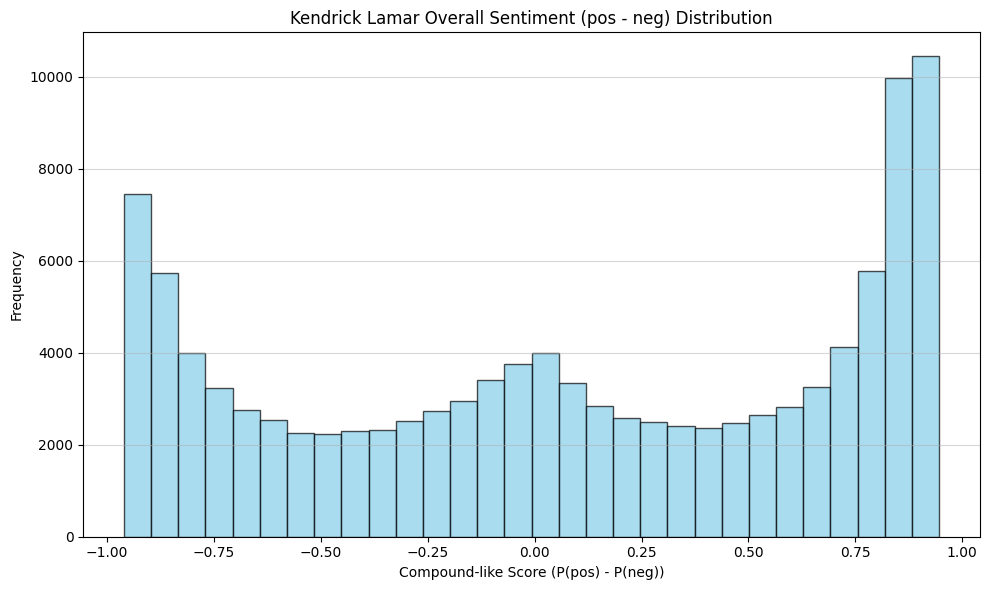

In [17]:
# ===========================================
# Sentiment analysis with CardiffNLP XLM-R (multilingual)
# Model: cardiffnlp/twitter-xlm-roberta-base-sentiment
# Outputs: P(neg), P(neu), P(pos) + a compound-like score (pos - neg)
# ===========================================

# 1. FIXED: Removed 'torch' from here to avoid the dependency conflict error
!pip -q install -U transformers accelerate sentencepiece

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Check if 'df' exists; if not, create a dummy one for demonstration
if 'df' not in locals():
    print("No DataFrame found. Creating a dummy example...")
    df = pd.DataFrame({'text': ["I love this product!", "This is terrible.", "It is okay."]})

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

# CardiffNLP sentiment models are typically ordered: 0=negative, 1=neutral, 2=positive
IDX_NEG, IDX_NEU, IDX_POS = 0, 1, 2

def xlm_sentiment_batch(text_list, batch_size=64, max_length=128):
    """
    Returns a DataFrame with columns:
      sent_neg, sent_neu, sent_pos (probabilities)
      sent_compound = sent_pos - sent_neg  (range approx [-1, 1])
      sent_label = argmax class label
    """
    probs_all = []

    # Ensure strings
    text_list = ["" if t is None else str(t) for t in text_list]

    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i + batch_size]
        # Tokenize
        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            probs_all.append(probs)

    if len(probs_all) == 0:
         return pd.DataFrame()

    probs_all = np.vstack(probs_all)
    neg = probs_all[:, IDX_NEG]
    neu = probs_all[:, IDX_NEU]
    pos = probs_all[:, IDX_POS]

    # Calculate compound-like score
    compound = pos - neg

    labels_idx = probs_all.argmax(axis=1)
    idx2label = {IDX_NEG: "negative", IDX_NEU: "neutral", IDX_POS: "positive"}
    labels = [idx2label[i] for i in labels_idx]

    return pd.DataFrame({
        "sent_neg": neg,
        "sent_neu": neu,
        "sent_pos": pos,
        "sent_compound": compound,
        "sent_label": labels
    })

# --- Run sentiment on your dataframe ---
print("Running sentiment analysis...")
texts = df["text"].fillna("").astype(str).tolist()
sent_scores = xlm_sentiment_batch(texts, batch_size=64, max_length=128)

# Attach to df
# Reset index ensures alignment if original df had gaps
# FIX: Drop existing sentiment columns if they exist to avoid duplicates
cols_to_drop = [c for c in sent_scores.columns if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

df = pd.concat([df.reset_index(drop=True), sent_scores.reset_index(drop=True)], axis=1)

# --- 2. FIXED: Overall sentiment summary ---
# Using simple column selection and mean() instead of .agg(name=(...))
cols_to_summarize = ["sent_compound", "sent_pos", "sent_neg", "sent_neu"]

# Calculate the mean for each selected column
mean_series = df[cols_to_summarize].mean().round(3)

# Create the sent_summary Series with custom index names
sent_summary = pd.Series({
    "avg_compound": mean_series["sent_compound"],
    "avg_pos": mean_series["sent_pos"],
    "avg_neg": mean_series["sent_neg"],
    "avg_neu": mean_series["sent_neu"]
})

print("=== Overall Sentiment Summary (XLM-R CardiffNLP) ===")
print(sent_summary, "\n")

# Label distribution
print("=== Sentiment Label Distribution ===")
print(df["sent_label"].value_counts(normalize=True).round(3), "\n")

# --- Histogram (compound-like) ---
plt.figure(figsize=(10, 6))
plt.hist(df["sent_compound"], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title("Kendrick Lamar Overall Sentiment (pos - neg) Distribution")
plt.xlabel("Compound-like Score (P(pos) - P(neg))")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

##Polished confidence-threshold method (XLM-R)

In [18]:
import numpy as np
import pandas as pd

def add_confidence_threshold_labels(
    df: pd.DataFrame,
    prob_cols=("sent_pos", "sent_neu", "sent_neg"),
    compound_col="sent_compound",
    tau=0.60,
    neutral_band=0.15,
    use_both_rules=True
) -> pd.DataFrame:
    df = df.copy()

    # confidence
    df["sent_conf"] = df[list(prob_cols)].max(axis=1)

    # argmax label -> FULL WORDS
    argmax_col = df[list(prob_cols)].idxmax(axis=1)
    mapping = {"sent_pos": "positive", "sent_neu": "neutral", "sent_neg": "negative"}
    df["sent_label_argmax"] = argmax_col.map(mapping)

    # start with argmax as default
    df["sent_label_polished"] = df["sent_label_argmax"]

    # apply confidence threshold
    df.loc[df["sent_conf"] < tau, "sent_label_polished"] = "neutral"

    # optionally apply a neutral band on compound for borderline polarity
    if use_both_rules:
        df.loc[df[compound_col].abs() < neutral_band, "sent_label_polished"] = "neutral"

    return df


# --- FIX: Ensure sentiment columns are in df before proceeding ---
# Assuming sent_scores was generated in the previous cell
if 'sent_scores' in globals():
    # Drop existing sentiment columns from df if they are incomplete or wrong
    cols_to_drop = [c for c in sent_scores.columns if c in df.columns]
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)
    # Concatenate df with the full sent_scores DataFrame
    df = pd.concat([df.reset_index(drop=True), sent_scores.reset_index(drop=True)], axis=1)
else:
    print("Warning: 'sent_scores' DataFrame not found. Please ensure the sentiment analysis cell ran correctly.")
# -----------------------------------------------------------------

# ---- Apply polishing ----
df = add_confidence_threshold_labels(
    df,
    tau=0.60,
    neutral_band=0.15,
    use_both_rules=True
)

print("=== Label distribution (argmax) ===")
print(df["sent_label_argmax"].value_counts(normalize=True).round(3), "\n")

print("=== Label distribution (polished) ===")
print(df["sent_label_polished"].value_counts(normalize=True).round(3), "\n")

print("=== Confidence summary ===")
print(df["sent_conf"].describe().round(3))

=== Label distribution (argmax) ===
sent_label_argmax
positive    0.442
negative    0.340
neutral     0.218
Name: proportion, dtype: float64 

=== Label distribution (polished) ===
sent_label_polished
neutral     0.390
positive    0.354
negative    0.255
Name: proportion, dtype: float64 

=== Confidence summary ===
count    111752.000
mean          0.720
std           0.173
min           0.335
25%           0.567
50%           0.747
75%           0.883
max           0.970
Name: sent_conf, dtype: float64


#Best way to integrate with BERTopic (hedonic vs symbolic evidence-based)

In [24]:
# ============================================================
# FIXED FULL CODE (Frame coding works: Hedonic / Symbolic / Hybrid / Other)
# - Fixes your regex bug (\ -> \b)
# - Improves frame detection by using TopicWords + Representative Docs as evidence
# - Keeps your BERTopic + XLM-R sentiment pipeline intact
# - Produces:
#     topic_summary_enriched (topic-level stats + Frame)
#     doc_info_enriched      (doc-level Topic + sentiment + Frame)
#     frame_sent             (frame-level sentiment summary)
# ============================================================

import re
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# -----------------------------
# 0) Preconditions
# -----------------------------
if "topic_model" not in globals():
    raise NameError("❌ 'topic_model' not found. Run your BERTopic training cell first.")
if "docs" not in globals():
    raise NameError("❌ 'docs' not found. 'docs' must be the exact list used in BERTopic.fit_transform().")

# -----------------------------
# 1) Get per-document topic assignments (aligned to docs)
# -----------------------------
doc_info = topic_model.get_document_info(docs).copy().reset_index(drop=True)

# -----------------------------
# 2) XLM-R sentiment on docs (guaranteed alignment)
# -----------------------------
MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

IDX_NEG, IDX_NEU, IDX_POS = 0, 1, 2

def xlm_sentiment_batch(text_list, batch_size=64, max_length=128):
    probs_all = []
    text_list = ["" if t is None else str(t) for t in text_list]

    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i + batch_size]
        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()

        probs_all.append(probs)

    probs_all = np.vstack(probs_all) if probs_all else np.zeros((0, 3))
    neg, neu, pos = probs_all[:, IDX_NEG], probs_all[:, IDX_NEU], probs_all[:, IDX_POS]
    compound = pos - neg

    return pd.DataFrame({
        "sent_neg": neg,
        "sent_neu": neu,
        "sent_pos": pos,
        "sent_compound": compound
    })

def add_confidence_threshold_labels(
    df_scores: pd.DataFrame,
    prob_cols=("sent_pos", "sent_neu", "sent_neg"),
    compound_col="sent_compound",
    tau=0.60,
    neutral_band=0.15,
    use_both_rules=True
) -> pd.DataFrame:
    df_scores = df_scores.copy()

    df_scores["sent_conf"] = df_scores[list(prob_cols)].max(axis=1)

    argmax_col = df_scores[list(prob_cols)].idxmax(axis=1)
    mapping = {"sent_pos": "positive", "sent_neu": "neutral", "sent_neg": "negative"}
    df_scores["sent_label_polished"] = argmax_col.map(mapping)

    df_scores.loc[df_scores["sent_conf"] < tau, "sent_label_polished"] = "neutral"
    if use_both_rules:
        df_scores.loc[df_scores[compound_col].abs() < neutral_band, "sent_label_polished"] = "neutral"

    return df_scores

print("✅ Running XLM-R sentiment on docs (aligned to BERTopic)...")
sent_scores = xlm_sentiment_batch(docs, batch_size=64, max_length=128)
sent_scores = add_confidence_threshold_labels(sent_scores, tau=0.60, neutral_band=0.15, use_both_rules=True)

if len(sent_scores) != len(doc_info):
    raise ValueError(f"❌ Alignment error: len(sent_scores)={len(sent_scores)} vs len(doc_info)={len(doc_info)}")

required_cols = ["sent_compound", "sent_pos", "sent_neg", "sent_neu", "sent_conf", "sent_label_polished"]
doc_info_enriched = pd.concat([doc_info, sent_scores[required_cols]], axis=1)

# -----------------------------
# 3) Aggregate sentiment by Topic
# -----------------------------
EXCLUDE_OUTLIERS = False
doc_for_topics = doc_info_enriched if not EXCLUDE_OUTLIERS else doc_info_enriched[doc_info_enriched["Topic"] != -1].copy()

agg_cols = ["sent_compound", "sent_pos", "sent_neg", "sent_neu", "sent_conf"]
topic_sent_stats = doc_for_topics.groupby("Topic")[agg_cols].mean().reset_index()

topic_label_rates = (
    doc_for_topics.groupby("Topic")["sent_label_polished"]
    .agg(
        pct_positive=lambda s: (s == "positive").mean(),
        pct_negative=lambda s: (s == "negative").mean(),
        pct_neutral=lambda s: (s == "neutral").mean(),
    )
    .reset_index()
)

topic_summary_enriched = (
    topic_model.get_topic_info()
    .merge(topic_sent_stats, on="Topic", how="left")
    .merge(topic_label_rates, on="Topic", how="left")
)

print("✅ topic_summary_enriched created.")
print(topic_summary_enriched.head())

# -----------------------------
# 4) Hedonic vs Symbolic frame coding (FIXED + STRONGER)
#    Uses evidence text = TopicWords + Representative Docs
# -----------------------------

# FIXED regex patterns: end with \b (word boundary), no weird \ character
HEDONIC_PAT = re.compile(
    r"(?i)\b(?:performance|show|music|song|setlist|vocals?|voice|dance|choreo(?:graphy)?|"
    r"stage|visuals?|sound|audio|mix|mic|camera|lighting|energy|hype|fun|"
    r"entertain(?:ing|ment)|boring|rewatch|watching\s+again|best\s+halftime|"
    r"worst\s+halftime|outstanding|nostalgia|hits|fire|lit|goat|mid|trash|"
    r"amazing|awesome|great|bad)\b"
)

SYMBOLIC_PAT = re.compile(
    r"(?i)\b(?:message|meaning|politic(?:s|al)?|representation|race|racist|identity|culture|"
    r"flag|protest|controversy|debate|snub|legacy|legend|censorship|"
    r"disrespect|moral|morality|values?|america|national(?:ism)?|"
    r"social\s+justice|beef|feud|diss|drake|lil\s+wayne|michael\s+jackson|mj)\b"
)

def assign_frame(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return "Other"
    hed = bool(HEDONIC_PAT.search(text))
    sym = bool(SYMBOLIC_PAT.search(text))
    if hed and sym:
        return "Hybrid"
    if hed:
        return "Hedonic"
    if sym:
        return "Symbolic"
    return "Other"

def topic_words_as_text(topic_id: int, top_n=25) -> str:
    if topic_id == -1:
        return ""
    words = topic_model.get_topic(topic_id) or []
    return " ".join([w for w, _ in words[:top_n]])

def topic_evidence_text(topic_id: int, top_n=25, n_docs=6, doc_char_limit=220) -> str:
    """
    Evidence text = TopicWords + representative docs.
    Improves frame matching vs keywords alone.
    """
    if topic_id == -1:
        return ""

    # topic keywords
    kw_text = topic_words_as_text(topic_id, top_n=top_n)

    # representative docs (if available)
    try:
        reps = topic_model.get_representative_docs(topic_id) or []
    except Exception:
        reps = []

    reps = [str(x).replace("\n", " ").strip()[:doc_char_limit] for x in reps[:n_docs]]
    rep_text = " ".join(reps)

    return f"{kw_text} {rep_text}".strip()

# Optional: use your Gemini topic labels if you have `labels` dict
if "labels" in globals() and isinstance(labels, dict):
    topic_summary_enriched["CustomName"] = topic_summary_enriched["Topic"].map(labels)
else:
    topic_summary_enriched["CustomName"] = np.nan

topic_summary_enriched["TopicWords"] = topic_summary_enriched["Topic"].apply(topic_words_as_text)
topic_summary_enriched["EvidenceText"] = topic_summary_enriched["Topic"].apply(topic_evidence_text)

# If CustomName exists, include it in EvidenceText
topic_summary_enriched["EvidenceText"] = (
    topic_summary_enriched["CustomName"].fillna("").astype(str) + " " + topic_summary_enriched["EvidenceText"]
).str.strip()

topic_summary_enriched["Frame"] = topic_summary_enriched["EvidenceText"].apply(assign_frame)

print("\n=== Frame distribution (topics) ===")
print(topic_summary_enriched["Frame"].value_counts(dropna=False))

# Map Topic -> Frame back to documents
topic_to_frame = dict(zip(topic_summary_enriched["Topic"], topic_summary_enriched["Frame"]))
doc_info_enriched["Frame"] = doc_info_enriched["Topic"].map(topic_to_frame).fillna("Other")

# -----------------------------
# 5) Frame-level sentiment summary
# -----------------------------
frame_sent = (
    doc_info_enriched.groupby("Frame", dropna=False)
    .agg(
        n_docs=("Frame", "size"),
        mean_compound=("sent_compound", "mean"),
        pct_positive=("sent_label_polished", lambda s: (s == "positive").mean()),
        pct_negative=("sent_label_polished", lambda s: (s == "negative").mean()),
        pct_neutral=("sent_label_polished", lambda s: (s == "neutral").mean()),
        mean_conf=("sent_conf", "mean"),
    )
    .reset_index()
)

frame_sent[["mean_compound", "pct_positive", "pct_negative", "pct_neutral", "mean_conf"]] = (
    frame_sent[["mean_compound", "pct_positive", "pct_negative", "pct_neutral", "mean_conf"]].round(3)
)

print("\n=== Frame-level sentiment summary ===")
print(frame_sent.sort_values("n_docs", ascending=False))

# -----------------------------
# 6) (Optional) Quick sanity debug: show a few topics per frame
# -----------------------------
print("\n=== Sample topics by Frame (top 3 per frame) ===")
for fr in ["Hedonic", "Symbolic", "Hybrid", "Other"]:
    sub = topic_summary_enriched[topic_summary_enriched["Frame"] == fr].head(3)
    if len(sub) == 0:
        print(f"\n[{fr}] (none)")
        continue
    print(f"\n[{fr}]")
    for _, r in sub.iterrows():
        print(f"- Topic {int(r['Topic'])}: {str(r.get('CustomName',''))[:60]} | Words: {str(r['TopicWords'])[:80]}")


✅ Using device: cuda
✅ Running XLM-R sentiment on docs (aligned to BERTopic)...
✅ topic_summary_enriched created.
   Topic  Count                        Name  \
0      0  10783       0_drake_drakes_say_he   
1      1   4331  1_kendrick_lamar_love_goat   
2      2  12713             2_and_to_of_the   
3      3   3579              3_de_que_el_la   
4      4   3396  4_best_ever_halftime_worst   

                                          CustomName  \
0   Kendrick Lamar smiling while saying Drake's name   
1  Expressing love and admiration for Kendrick Lamar   
2  Mixed reactions to Kendrick Lamar halftime per...   
3  Analysis of Kendrick Lamar's performance and a...   
4         Best Super Bowl halftime shows of all-time   

                                      Representation  \
0  [drake, drakes, say, he, hey, at, his, smile, ...   
1  [kendrick, lamar, love, goat, is, sza, you, ki...   
2  [and, to, of, the, but, you, people, that, it,...   
3         [de, que, el, la, es, en, un, lo

In [25]:
# ============================
# EXPORT FULL RESULTS TO GOOGLE DRIVE (Excel)
# ============================
# 2) Choose output path
output_path = "/content/drive/MyDrive/Data/SBHT/lamar_full_results.xlsx"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# 3) Excel row limit safety check (Excel hard limit = 1,048,576 rows per sheet)
EXCEL_MAX_ROWS = 1_048_576
too_big = len(doc_info_enriched) > EXCEL_MAX_ROWS

with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    # Topic-level summary + sentiment stats + frame assignment
    topic_summary_enriched.to_excel(writer, sheet_name="Topic_Summary", index=False)

    # Frame-level sentiment summary
    frame_sent.to_excel(writer, sheet_name="Frame_Sentiment", index=False)

    # Document-level assignments (can be huge)
    if not too_big:
        doc_info_enriched.to_excel(writer, sheet_name="Doc_Assignments", index=False)
    else:
        # If too big for Excel, write only the first chunk to Excel
        doc_info_enriched.head(EXCEL_MAX_ROWS).to_excel(writer, sheet_name="Doc_Assignments_Head", index=False)

print(f"✅ Exported Excel to: {output_path}")

# 4) If doc_info_enriched is too large for Excel, also export as CSV (recommended)
if too_big:
    csv_path = output_path.replace(".xlsx", "_Doc_Assignments.csv.gz")
    doc_info_enriched.to_csv(csv_path, index=False, compression="gzip")
    print(f"⚠️ doc_info_enriched has {len(doc_info_enriched):,} rows (exceeds Excel limit).")
    print(f"✅ Saved full Doc_Assignments as compressed CSV to: {csv_path}")


✅ Exported Excel to: /content/drive/MyDrive/Data/SBHT/lamar_full_results.xlsx


In [21]:
# -----------------------------
# 5) Export
# -----------------------------
# 1. Choose a Drive path
output_path = "/content/drive/MyDrive/Data/SBHT/lamar_bertopic_xlmr_topic_sentiment.xlsx"

# 2. Create folders if they don't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# 3. Build the tables you want to export (your variables assumed to exist)
topic_summary = topic_model.get_topic_info().copy()
topic_summary["CustomName"] = topic_summary["Topic"].map(labels)  # labels must be dict-like

doc_info = doc_info_enriched.copy()  # or: topic_model.get_document_info(docs).copy()
# doc_info["RawText"] = raw_docs     # if you have raw_docs

# 4. Write to Excel on Drive
with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    topic_summary.to_excel(writer, sheet_name="Topic_Summary", index=False)
    doc_info.to_excel(writer, sheet_name="Assignments", index=False)
    topic_summary_enriched.to_excel(writer, sheet_name="Topic_Sentiment", index=False)
    frame_sent.to_excel(writer, sheet_name="Frame_Summary", index=False)

print(f"✅ Exported to: {output_path}")

✅ Exported to: /content/drive/MyDrive/Data/SBHT/lamar_bertopic_xlmr_topic_sentiment.xlsx


#Evidence-based “hedonic vs symbolic” coding (semi-automatic, reproducible)

In [ ]:
import re
import pandas as pd
import numpy as np

# ==========================================
# 0. Self-Correction: Ensure topic_summary_enriched exists
# ==========================================
if 'topic_summary_enriched' not in globals():
    print("⚠️ 'topic_summary_enriched' not found. Attempting to reconstruct it from 'topic_model' and 'df'...")

    # 1. Check prerequisites
    if 'topic_model' not in globals():
        raise NameError("Critical: 'topic_model' is not defined. Please run the BERTopic training cell.")

    # 2. Check for sentiment data in df
    required_sent_cols = ["sent_compound", "sent_pos", "sent_neg", "sent_neu", "sent_conf", "sent_label_polished"]
    has_df_sent = 'df' in globals() and all(c in df.columns for c in required_sent_cols)

    if has_df_sent:
        print("   Found sentiment data in 'df'. Aggregating stats by Topic...")

        # Use existing doc_info or create new one
        if 'doc_info' in globals() and len(doc_info) == len(df):
            di = doc_info.copy()
        else:
            # Assuming 'docs' is available or derive from df
            docs_source = docs if 'docs' in globals() else df['clean_text'].tolist()
            di = topic_model.get_document_info(docs_source).copy()

        # Attach sentiment columns safely
        df_reset = df.reset_index(drop=True)
        di = pd.concat([di.reset_index(drop=True), df_reset[required_sent_cols]], axis=1)

        # Aggregate Sentiment Stats
        agg_cols = ["sent_compound", "sent_pos", "sent_neg", "sent_neu", "sent_conf"]
        stats = di.groupby("Topic")[agg_cols].mean().reset_index()

        # Aggregate Positive Percentage
        def get_pos_pct(x): return (x == "positive").mean()
        pos_pct = di.groupby("Topic")["sent_label_polished"].apply(get_pos_pct).reset_index(name="pct_positive")

        # Merge into topic_summary_enriched
        topic_summary_enriched = pd.merge(topic_model.get_topic_info(), stats, on="Topic", how="left")
        topic_summary_enriched = pd.merge(topic_summary_enriched, pos_pct, on="Topic", how="left")

    else:
        # Fallback: Create basic table without sentiment if sentiment is missing
        print("⚠️ Sentiment columns missing in 'df'. Creating basic summary without sentiment stats.")
        topic_summary_enriched = topic_model.get_topic_info().copy()


# ==========================================
# 1. Ensure CustomName exists (Labeling)
# ==========================================
if "CustomName" not in topic_summary_enriched.columns:
    # Try to map from 'labels' dict if available from the Gemini step
    if 'labels' in globals():
        topic_summary_enriched["CustomName"] = topic_summary_enriched["Topic"].map(labels)
    else:
        # Fallback to default Name if no custom labels found
        print("⚠️ 'labels' dictionary not found. Using default Topic Names for framing.")
        topic_summary_enriched["CustomName"] = topic_summary_enriched["Name"]

# ==========================================
# 2. Define Patterns (Hedonic vs Symbolic)
# ==========================================
HEDONIC_PAT = re.compile(
    r"\b(performance|show|music|song|setlist|vocals|voice|dance|choreo|stage|visuals|"
    r"sound|audio|mix|mic|camera|lighting|energy|hype|fun|entertaining|boring|"
    r"rewatch|watching again|best halftime|worst halftime|outstanding)\b",
    flags=re.IGNORECASE
)

SYMBOLIC_PAT = re.compile(
    r"\b(message|meaning|politic|representation|race|racist|identity|culture|"
    r"palestine|sudan|flag|protest|controversy|debate|snub|"
    r"drake|lil wayne|beef|feud|diss|legacy|legend|mj|michael jackson)\b",
    flags=re.IGNORECASE
)

# ==========================================
# 3. Assignment Function
# ==========================================
def assign_frame(label: str) -> str:
    if not isinstance(label, str) or not label.strip():
        return "Other"
    hed = bool(HEDONIC_PAT.search(label))
    sym = bool(SYMBOLIC_PAT.search(label))
    if hed and sym:
        return "Hybrid"
    if hed:
        return "Hedonic"
    if sym:
        return "Symbolic"
    return "Other"

# ==========================================
# 4. Apply & Check
# ==========================================
topic_summary_enriched["Frame"] = topic_summary_enriched["CustomName"].apply(assign_frame)

print("=== Topic Frame Distribution ===")
print(topic_summary_enriched["Frame"].value_counts(dropna=False))

=== Topic Frame Distribution ===
Frame
Other       63
Hedonic     31
Symbolic     8
Name: count, dtype: int64


In [ ]:
# Self-Correction: Ensure 'Topic' column exists in df
if "Topic" not in df.columns:
    if "doc_info" in globals() and len(doc_info) == len(df):
         print("⚠️ 'Topic' column missing in df. Copying from doc_info...")
         df["Topic"] = doc_info["Topic"].values
    else:
         raise KeyError("Cannot find 'Topic' column in df, and doc_info is missing or misaligned.")

# Map topic -> frame
topic_to_frame = dict(zip(topic_summary_enriched["Topic"], topic_summary_enriched["Frame"]))
df["Frame"] = df["Topic"].map(topic_to_frame).fillna("Other")

frame_sent = (df
    .groupby("Frame")
    .agg(
        n_docs=("Frame", "size"),
        mean_compound=("sent_compound", "mean"),
        pct_pos=("sent_label_polished", lambda s: (s == "positive").mean()),
        pct_neg=("sent_label_polished", lambda s: (s == "negative").mean()),
        pct_neu=("sent_label_polished", lambda s: (s == "neutral").mean()),
        mean_conf=("sent_conf", "mean"),
    )
    .reset_index()
)

frame_sent[["mean_compound","pct_pos","pct_neg","pct_neu","mean_conf"]] = \
    frame_sent[["mean_compound","pct_pos","pct_neg","pct_neu","mean_conf"]].round(3)

print(frame_sent.sort_values("n_docs", ascending=False))

⚠️ 'Topic' column missing in df. Copying from doc_info...
      Frame  n_docs  mean_compound  pct_pos  pct_neg  pct_neu  mean_conf
1     Other   50943          0.058    0.337    0.265    0.398      0.718
0   Hedonic   46741          0.150    0.422    0.229    0.349      0.738
2  Symbolic   14068         -0.108    0.195    0.304    0.501      0.669


In [ ]:
import os

# 1. Define output_path (Missing variable)
output_path = "/content/drive/MyDrive/Data/SBHT/lamar_bertopic_finetuned_results2.xlsx"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# 2. Ensure topic_summary exists (in case it wasn't defined earlier)
if 'topic_summary' not in globals():
    topic_summary = topic_model.get_topic_info()

# 3. Export
with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    topic_summary.to_excel(writer, sheet_name="Topic_Summary", index=False)
    doc_info.to_excel(writer, sheet_name="Assignments", index=False)

    # NEW:
    topic_summary_enriched.to_excel(writer, sheet_name="Topic_Sentiment", index=False)
    frame_sent.to_excel(writer, sheet_name="Frame_Summary", index=False)

print(f"✅ Exported to: {output_path}")

✅ Exported to: /content/drive/MyDrive/Data/SBHT/lamar_bertopic_finetuned_results2.xlsx
